<a href="https://colab.research.google.com/github/HediJamaa/Breast-cancer-classification-IA-agent-Projet-ISG-Tunis-/blob/main/projetdm_ideas26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# Importer le dataset Breast Cancer Wisconsin Diagnostic
breast_cancer = fetch_ucirepo(id=17)

# Les variables explicatives X
X = breast_cancer.data.features

# La variable cible y
y = breast_cancer.data.targets

# Afficher les premières lignes
display(X.head())
display(y.head())

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,Diagnosis
0,M
1,M
2,M
3,M
4,M


In [ ]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nNombre de classes:")
print(y["Diagnosis"].value_counts())

Shape of X: (569, 30)
Shape of y: (569, 1)

Nombre de classes:
Diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# Transformation de la classe
# M = 1 : malignant
# B = 0 : benign

y = y["Diagnosis"]

y = y.map({
    "M": 1,
    "B": 0
})

print(y.head())
print(y.value_counts())

0    1
1    1
2    1
3    1
4    1
Name: Diagnosis, dtype: int64
Diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split #devisedataset
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Fonction pour calculer TP, TN, FP, FN et les métriques
def calculate_metrics(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    # Matrice :
    # [[TN, FP],
    #  [FN, TP]]
    TN, FP, FN, TP = cm.ravel()

    error_rate = (FP + FN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    fmeasure = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return TP, TN, FP, FN, error_rate, precision, recall, fmeasure


# Les deux algorithmes retenus
models = {
    "SVM": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

# Moyenne sur 5 itérations
for model_name, model in models.items():

    TP_list = []
    TN_list = []
    FP_list = []
    FN_list = []
    error_list = []
    precision_list = []
    recall_list = []
    fmeasure_list = []

    print("\n==============================")
    print("Algorithm:", model_name)
    print("==============================")

    for i in range(5):

        # Division train/test sans prétraitement
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42 + i,
            stratify=y
        )

        # Apprentissage du modèle
        model.fit(X_train, y_train)

        # Prédiction
        y_pred = model.predict(X_test)

        # Calcul des mesures
        TP, TN, FP, FN, error_rate, precision, recall, fmeasure = calculate_metrics(y_test, y_pred)

        TP_list.append(TP)
        TN_list.append(TN)
        FP_list.append(FP)
        FN_list.append(FN)
        error_list.append(error_rate)
        precision_list.append(precision)
        recall_list.append(recall)
        fmeasure_list.append(fmeasure)

        print("\nIteration", i + 1)
        print("TP =", TP)
        print("TN =", TN)
        print("FP =", FP)
        print("FN =", FN)

    results.append({
        "Dataset": "Breast Cancer Wisconsin Diagnostic",
        "Protocol": "Without preprocessing",
        "Algorithm": model_name,
        "TP": np.mean(TP_list),
        "TN": np.mean(TN_list),
        "FP": np.mean(FP_list),
        "FN": np.mean(FN_list),
        "Error Rate": np.mean(error_list),
        "Precision": np.mean(precision_list),
        "Recall": np.mean(recall_list),
        "Fmeasure": np.mean(fmeasure_list)
    })


# Tableau final du protocole 1
protocol1_results = pd.DataFrame(results)

display(protocol1_results)


Algorithm: SVM

Iteration 1
TP = 31
TN = 72
FP = 0
FN = 11

Iteration 2
TP = 32
TN = 69
FP = 3
FN = 10

Iteration 3
TP = 31
TN = 69
FP = 3
FN = 11

Iteration 4
TP = 35
TN = 70
FP = 2
FN = 7

Iteration 5
TP = 36
TN = 70
FP = 2
FN = 6

Algorithm: KNN

Iteration 1
TP = 33
TN = 71
FP = 1
FN = 9

Iteration 2
TP = 35
TN = 67
FP = 5
FN = 7

Iteration 3
TP = 38
TN = 67
FP = 5
FN = 4

Iteration 4
TP = 35
TN = 66
FP = 6
FN = 7

Iteration 5
TP = 40
TN = 68
FP = 4
FN = 2


,Dataset,Protocol,Algorithm,TP,TN,FP,FN,Error Rate,Precision,Recall,Fmeasure
0,Breast Cancer Wisconsin Diagnostic,Without preprocessing,SVM,33.0,70.0,2.0,9.0,0.096491,0.943873,0.785714,0.856470
1,Breast Cancer Wisconsin Diagnostic,Without preprocessing,KNN,36.2,67.8,4.2,5.8,0.087719,0.898412,0.861905,0.877961


In [ ]:
# Protocol 2: Preprocessing


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# Créer une copie du dataset
X_preprocessed = X.copy()
y_preprocessed = y.copy()

# 1. Vérifier et supprimer les doublons
df_full = pd.concat([X_preprocessed, y_preprocessed], axis=1)
print("Shape before removing duplicates:", df_full.shape)

df_full = df_full.drop_duplicates()
print("Shape after removing duplicates:", df_full.shape)

# Séparer X et y après suppression des doublons
X_preprocessed = df_full.drop(columns=["Diagnosis"])
y_preprocessed = df_full["Diagnosis"]

# 2. Vérifier les valeurs manquantes
print("\nMissing values:")
print(X_preprocessed.isnull().sum().sum())

# 3. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_preprocessed)

# 4. Sélection des meilleures features
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X_scaled, y_preprocessed)

# 5. Réduction de dimension avec PCA - réduire le nombre features tout en gardant le maximum d’information possible.
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_selected)

print("\nShape after preprocessing:", X_pca.shape)

Shape before removing duplicates: (569, 31)
Shape after removing duplicates: (569, 31)

Missing values:
0

Shape after preprocessing: (569, 10)


In [ ]:
# ============================================================
# Evaluation of Protocol 2: With Preprocessing
# ============================================================

models = {
    "SVM": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results_protocol2 = []

for model_name, model in models.items():

    TP_list = []
    TN_list = []
    FP_list = []
    FN_list = []
    error_list = []
    precision_list = []
    recall_list = []
    fmeasure_list = []

    print("\n==============================")
    print("Algorithm:", model_name)
    print("==============================")

    for i in range(5):

        X_train, X_test, y_train, y_test = train_test_split(
            X_pca,
            y_preprocessed,
            test_size=0.2,
            random_state=42 + i,
            stratify=y_preprocessed
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        TP, TN, FP, FN, error_rate, precision, recall, fmeasure = calculate_metrics(
            y_test,
            y_pred
        )

        TP_list.append(TP)
        TN_list.append(TN)
        FP_list.append(FP)
        FN_list.append(FN)
        error_list.append(error_rate)
        precision_list.append(precision)
        recall_list.append(recall)
        fmeasure_list.append(fmeasure)

        print("\nIteration", i + 1)
        print("TP =", TP)
        print("TN =", TN)
        print("FP =", FP)
        print("FN =", FN)

    results_protocol2.append({
        "Dataset": "Breast Cancer Wisconsin Diagnostic",
        "Protocol": "With preprocessing",
        "Algorithm": model_name,
        "TP": np.mean(TP_list),
        "TN": np.mean(TN_list),
        "FP": np.mean(FP_list),
        "FN": np.mean(FN_list),
        "Error Rate": np.mean(error_list),
        "Precision": np.mean(precision_list),
        "Recall": np.mean(recall_list),
        "Fmeasure": np.mean(fmeasure_list)
    })

protocol2_results = pd.DataFrame(results_protocol2)

display(protocol2_results)


Algorithm: SVM

Iteration 1
TP = 40
TN = 71
FP = 1
FN = 2

Iteration 2
TP = 41
TN = 70
FP = 2
FN = 1

Iteration 3
TP = 36
TN = 70
FP = 2
FN = 6

Iteration 4
TP = 40
TN = 72
FP = 0
FN = 2

Iteration 5
TP = 42
TN = 71
FP = 1
FN = 0

Algorithm: KNN

Iteration 1
TP = 38
TN = 71
FP = 1
FN = 4

Iteration 2
TP = 41
TN = 70
FP = 2
FN = 1

Iteration 3
TP = 36
TN = 71
FP = 1
FN = 6

Iteration 4
TP = 39
TN = 72
FP = 0
FN = 3

Iteration 5
TP = 42
TN = 69
FP = 3
FN = 0


,Dataset,Protocol,Algorithm,TP,TN,FP,FN,Error Rate,Precision,Recall,Fmeasure
0,Breast Cancer Wisconsin Diagnostic,With preprocessing,SVM,39.8,70.8,1.2,2.2,0.029825,0.970642,0.947619,0.958481
1,Breast Cancer Wisconsin Diagnostic,With preprocessing,KNN,39.2,70.6,1.4,2.8,0.036842,0.966831,0.933333,0.948570


In [ ]:
# ============================================================
# Final comparison table in the format required by the project
# ============================================================

final_comparison = pd.DataFrame({
    "Name_Dataset": ["Without preprocessing", "With preprocessing"],

    "SVM Error Rate": [
        0.096491,
        0.029825
    ],
    "SVM Precision": [
        0.943873,
        0.970642
    ],
    "SVM Recall": [
        0.785714,
        0.947619
    ],
    "SVM F_measure": [
        0.856470,
        0.958481
    ],

    "KNN Error Rate": [
        0.087719,
        0.036842
    ],
    "KNN Precision": [
        0.898412,
        0.966831
    ],
    "KNN Recall": [
        0.861905,
        0.933333
    ],
    "KNN F_measure": [
        0.877961,
        0.948570
    ]
})

display(final_comparison)

,Name_Dataset,SVM Error Rate,SVM Precision,SVM Recall,SVM F_measure,KNN Error Rate,KNN Precision,KNN Recall,KNN F_measure
0,Without preprocessing,0.096491,0.943873,0.785714,0.856470,0.087719,0.898412,0.861905,0.877961
1,With preprocessing,0.029825,0.970642,0.947619,0.958481,0.036842,0.966831,0.933333,0.948570


In [ ]:
# ============================================================
# $Intelligent Agent for the Complete Pipeline
# Protocol 2: With Preprocessing
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

import pandas as pd
import numpy as np


class IntelligentClassificationAgent:

    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.results = []
        self.best_model = None

    def analyze_dataset(self):
        print("Step 1: Dataset Analysis")
        print("Number of instances:", self.X.shape[0])
        print("Number of features:", self.X.shape[1])
        print("Number of missing values:", self.X.isnull().sum().sum())
        print("Class distribution:")
        print(self.y.value_counts())
        print("-" * 60)

    def preprocess_data(self):
        print("Step 2: Preprocessing")

        # Create full dataframe
        df = pd.concat([self.X, self.y], axis=1)

        # 1. Remove duplicates
        before = df.shape[0]
        df = df.drop_duplicates()
        after = df.shape[0]
        print("Duplicates removed:", before - after)

        # Separate X and y
        X_clean = df.drop(columns=["Diagnosis"])
        y_clean = df["Diagnosis"]

        # 2. Missing values verification
        missing_values = X_clean.isnull().sum().sum()
        print("Missing values:", missing_values)

        # 3. Standardization
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_clean)
        print("Standardization applied.")

        # 4. Feature selection
        selector = SelectKBest(score_func=f_classif, k=20)
        X_selected = selector.fit_transform(X_scaled, y_clean)
        print("Feature selection applied: 20 best features selected.")

        # 5. PCA
        pca = PCA(n_components=10)
        X_pca = pca.fit_transform(X_selected)
        print("PCA applied: data reduced to 10 components.")

        print("Final shape after preprocessing:", X_pca.shape)
        print("-" * 60)

        return X_pca, y_clean

    def calculate_metrics(self, y_test, y_pred):
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

        TN, FP, FN, TP = cm.ravel()

        error_rate = (FP + FN) / (TP + TN + FP + FN)
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        fmeasure = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) != 0
            else 0
        )

        return TP, TN, FP, FN, error_rate, precision, recall, fmeasure

    def train_and_evaluate(self, X_processed, y_processed):
        print("Step 3: Training and Evaluation")

        models = {
            "SVM": SVC(kernel="rbf"),
            "KNN": KNeighborsClassifier(n_neighbors=5)
        }

        for model_name, model in models.items():

            TP_list = []
            TN_list = []
            FP_list = []
            FN_list = []
            error_list = []
            precision_list = []
            recall_list = []
            fmeasure_list = []

            print("\nAlgorithm:", model_name)

            for i in range(5):

                X_train, X_test, y_train, y_test = train_test_split(
                    X_processed,
                    y_processed,
                    test_size=0.2,
                    random_state=42 + i,
                    stratify=y_processed
                )

                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

                TP, TN, FP, FN, error_rate, precision, recall, fmeasure = self.calculate_metrics(
                    y_test,
                    y_pred
                )

                TP_list.append(TP)
                TN_list.append(TN)
                FP_list.append(FP)
                FN_list.append(FN)
                error_list.append(error_rate)
                precision_list.append(precision)
                recall_list.append(recall)
                fmeasure_list.append(fmeasure)

                print("Iteration", i + 1, ": TP =", TP, "TN =", TN, "FP =", FP, "FN =", FN)

            self.results.append({
                "Protocol": "With preprocessing - Intelligent Agent",
                "Algorithm": model_name,
                "TP": np.mean(TP_list),
                "TN": np.mean(TN_list),
                "FP": np.mean(FP_list),
                "FN": np.mean(FN_list),
                "Error Rate": np.mean(error_list),
                "Precision": np.mean(precision_list),
                "Recall": np.mean(recall_list),
                "Fmeasure": np.mean(fmeasure_list)
            })

        print("-" * 60)

    def select_best_model(self):
        print("Step 4: Best Model Selection")

        results_df = pd.DataFrame(self.results)

        # The best model is selected according to the highest F-measure
        best_index = results_df["Fmeasure"].idxmax()
        self.best_model = results_df.loc[best_index]

        print("The best model selected by the agent is:")
        print("Algorithm:", self.best_model["Algorithm"])
        print("F-measure:", self.best_model["Fmeasure"])
        print("Error Rate:", self.best_model["Error Rate"])
        print("-" * 60)

        return results_df

    def run(self):
        print("Starting Intelligent Classification Agent")
        print("=" * 60)

        self.analyze_dataset()
        X_processed, y_processed = self.preprocess_data()
        self.train_and_evaluate(X_processed, y_processed)
        results_df = self.select_best_model()

        print("Final Results:")
        display(results_df)

        return results_df

In [ ]:
# Create and run the intelligent agent
agent = IntelligentClassificationAgent(X, y)

bonus_results = agent.run()

Starting Intelligent Classification Agent
Step 1: Dataset Analysis
Number of instances: 569
Number of features: 30
Number of missing values: 0
Class distribution:
Diagnosis
0    357
1    212
Name: count, dtype: int64
------------------------------------------------------------
Step 2: Preprocessing
Duplicates removed: 0
Missing values: 0
Standardization applied.
Feature selection applied: 20 best features selected.
PCA applied: data reduced to 10 components.
Final shape after preprocessing: (569, 10)
------------------------------------------------------------
Step 3: Training and Evaluation

Algorithm: SVM
Iteration 1 : TP = 40 TN = 71 FP = 1 FN = 2
Iteration 2 : TP = 41 TN = 70 FP = 2 FN = 1
Iteration 3 : TP = 36 TN = 70 FP = 2 FN = 6
Iteration 4 : TP = 40 TN = 72 FP = 0 FN = 2
Iteration 5 : TP = 42 TN = 71 FP = 1 FN = 0

Algorithm: KNN
Iteration 1 : TP = 38 TN = 71 FP = 1 FN = 4
Iteration 2 : TP = 41 TN = 70 FP = 2 FN = 1
Iteration 3 : TP = 36 TN = 71 FP = 1 FN = 6
Iteration 4 : TP 

,Protocol,Algorithm,TP,TN,FP,FN,Error Rate,Precision,Recall,Fmeasure
0,With preprocessing - Intelligent Agent,SVM,39.8,70.8,1.2,2.2,0.029825,0.970642,0.947619,0.958481
1,With preprocessing - Intelligent Agent,KNN,39.2,70.6,1.4,2.8,0.036842,0.966831,0.933333,0.948570


In [ ]:

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

# Transformer y en série simple
y = y["Diagnosis"]

# Vérifier
print(y.value_counts())

Diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# ============================================================
# Complete code: train the model + test a new instance
# ============================================================


import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# 1. Load dataset
breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets["Diagnosis"]

# 2. Convert target
# B = 0 : Benign
# M = 1 : Malignant
y_num = y.map({
    "B": 0,
    "M": 1
})

# 3. Preprocessing
df_full = pd.concat([X, y_num.rename("Diagnosis")], axis=1)
df_full = df_full.drop_duplicates()

X_preprocessed = df_full.drop(columns=["Diagnosis"])
y_preprocessed = df_full["Diagnosis"]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_preprocessed)

# Feature selection
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X_scaled, y_preprocessed)

# PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_selected)

# 4. Train final SVM model
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y_preprocessed,
    test_size=0.2,
    random_state=42,
    stratify=y_preprocessed
)

svm_model = SVC(kernel="rbf", probability=True)
svm_model.fit(X_train, y_train)

print("Model trained successfully.")
print("Ready to test a new instance.")

In [ ]:
# ============================================================
# Test a new tumor instance
# ============================================================

new_case = pd.DataFrame([{
    "radius1": 17.99,
    "texture1": 10.38,
    "perimeter1": 122.80,
    "area1": 1001.0,
    "smoothness1": 0.11840,
    "compactness1": 0.27760,
    "concavity1": 0.30010,
    "concave_points1": 0.14710,
    "symmetry1": 0.2419,
    "fractal_dimension1": 0.07871,
    "radius2": 1.0950,
    "texture2": 0.9053,
    "perimeter2": 8.589,
    "area2": 153.40,
    "smoothness2": 0.006399,
    "compactness2": 0.04904,
    "concavity2": 0.05373,
    "concave_points2": 0.01587,
    "symmetry2": 0.03003,
    "fractal_dimension2": 0.006193,
    "radius3": 25.38,
    "texture3": 17.33,
    "perimeter3": 184.60,
    "area3": 2019.0,
    "smoothness3": 0.1622,
    "compactness3": 0.6656,
    "concavity3": 0.7119,
    "concave_points3": 0.2654,
    "symmetry3": 0.4601,
    "fractal_dimension3": 0.11890
}])

# Apply the same preprocessing
new_case_scaled = scaler.transform(new_case)
new_case_selected = selector.transform(new_case_scaled)
new_case_pca = pca.transform(new_case_selected)

# Prediction
prediction = svm_model.predict(new_case_pca)

# Probability
probability = svm_model.predict_proba(new_case_pca)

print("Prediction code:", prediction[0])

if prediction[0] == 0:
    print("Prediction: Benign tumor / tumeur bénigne")
else:
    print("Prediction: Malignant tumor / tumeur maligne")

print("Probability Benign:", probability[0][0])
print("Probability Malignant:", probability[0][1])

Prediction code: 1
Prediction: Malignant tumor / tumeur maligne
Probability Benign: 0.02982733726531119
Probability Malignant: 0.9701726627346886


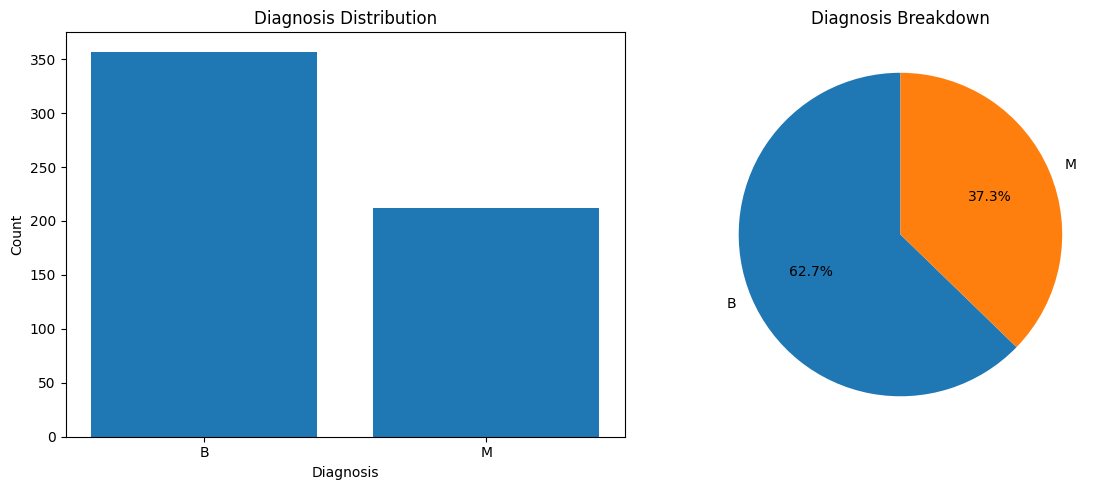

In [ ]:
class_counts = y.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title("Diagnosis Distribution")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Diagnosis Breakdown")

plt.tight_layout()
plt.savefig("diagnosis_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

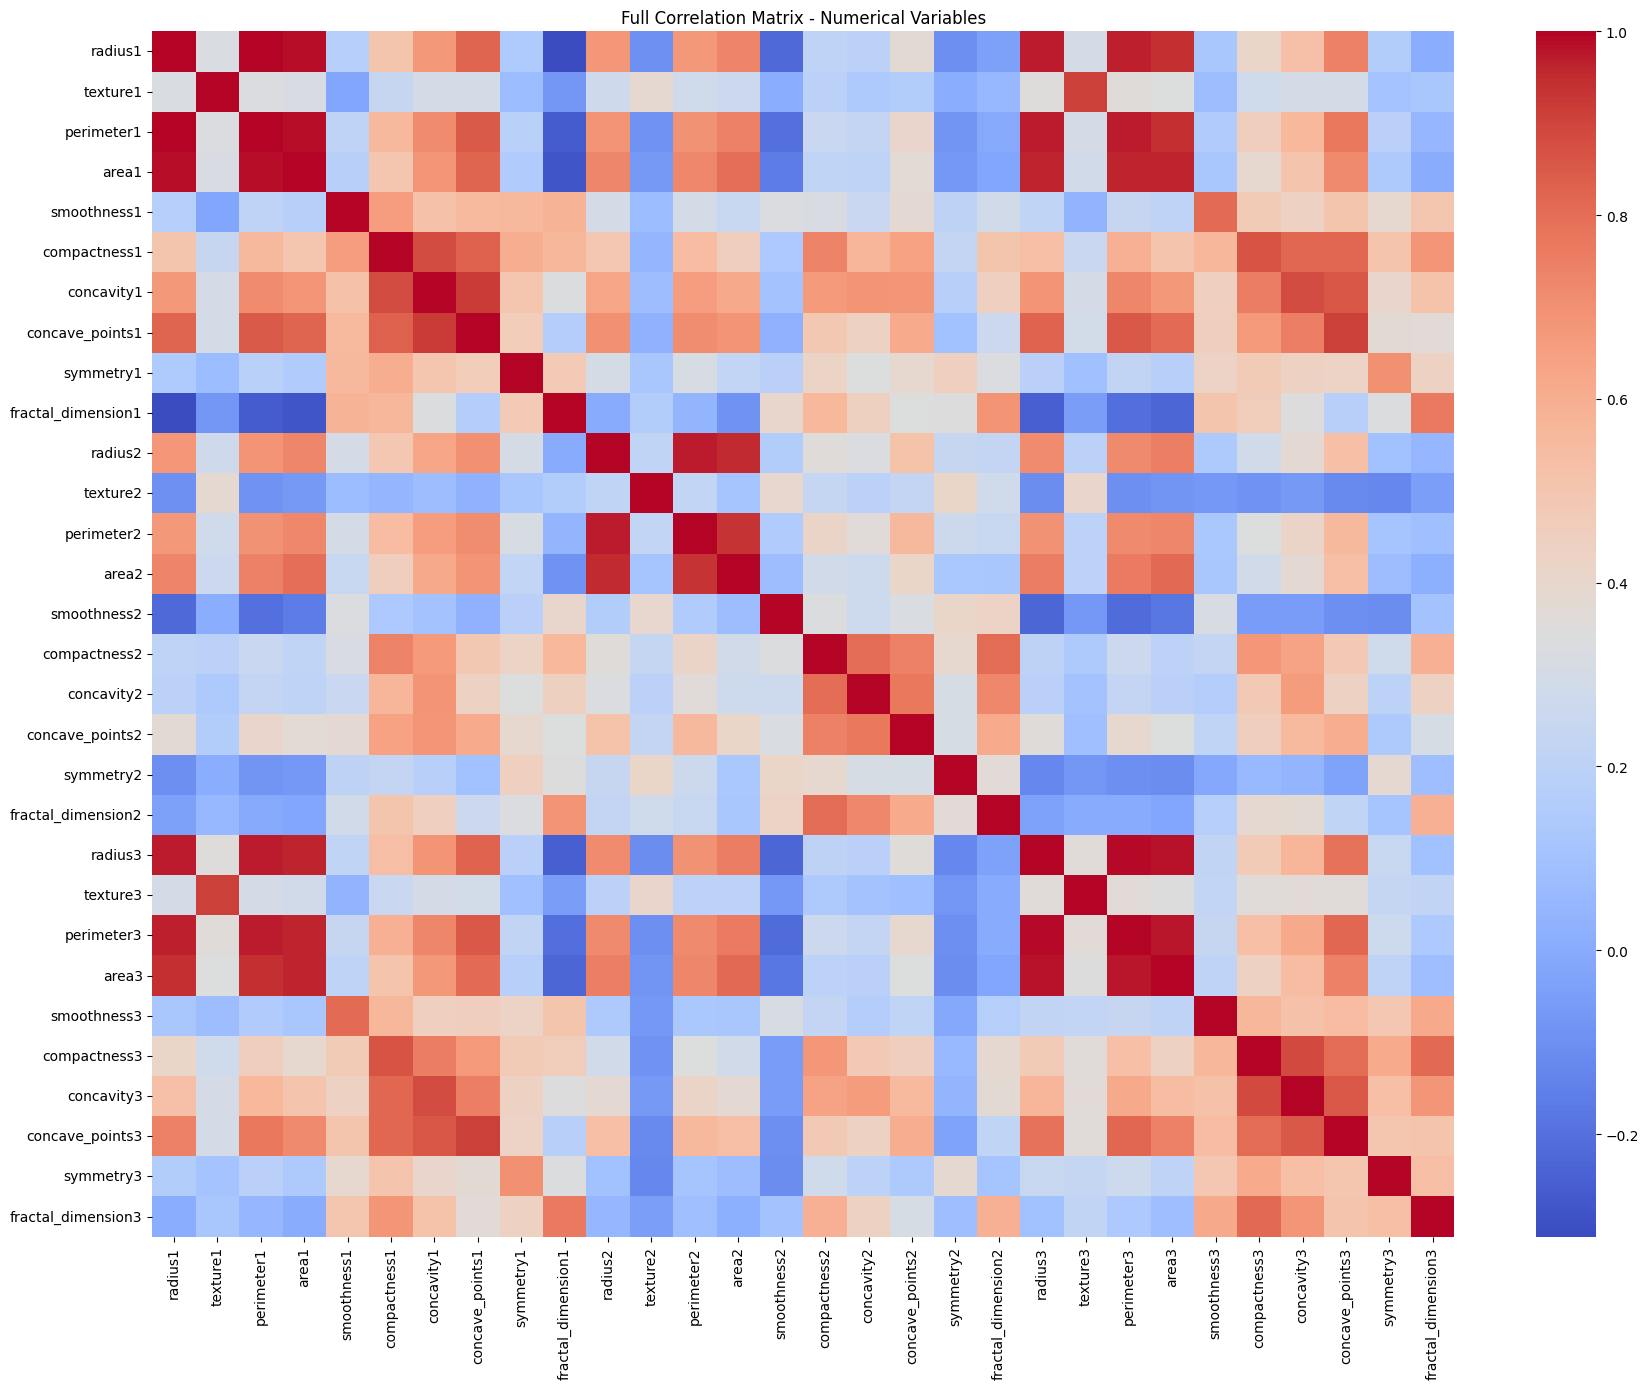

In [ ]:
import seaborn as sns

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Full Correlation Matrix - Numerical Variables")
plt.tight_layout()
plt.savefig("correlation_heatmap_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_843/3868841840.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X_subset_scaled, labels=existing_features, vert=True)


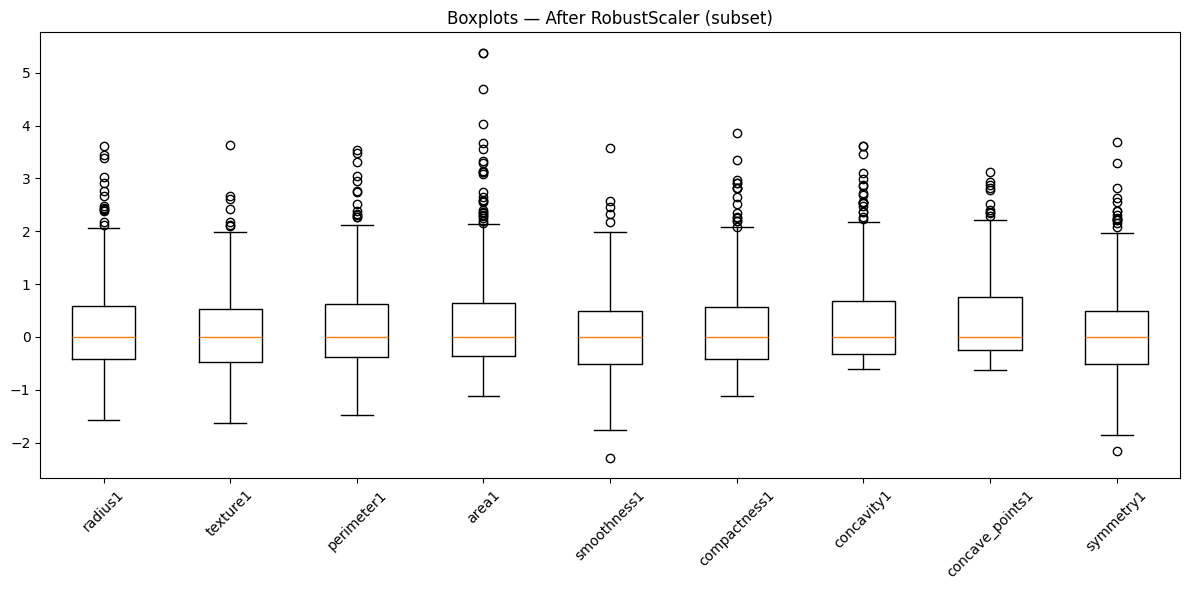

In [ ]:
from sklearn.preprocessing import RobustScaler

selected_features = [
    "radius1", "texture1", "perimeter1", "area1",
    "smoothness1", "compactness1", "concavity1",
    "concave_points1", "symmetry1"
]

# Vérifier les noms exacts selon ton dataset
existing_features = [col for col in selected_features if col in X.columns]

X_subset = X[existing_features].copy()

scaler = RobustScaler()
X_subset_scaled = scaler.fit_transform(X_subset)

plt.figure(figsize=(12, 6))
plt.boxplot(X_subset_scaled, labels=existing_features, vert=True)
plt.title("Boxplots — After RobustScaler (subset)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("boxplot_subset.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Complete Visualization Code for Breast Cancer Project
# Dataset: Breast Cancer Wisconsin Diagnostic
# ============================================================


# Libraries
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


# ============================================================
# 1. Load Dataset
# ============================================================

breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets["Diagnosis"]

# Convert target variable
# B = 0: Benign
# M = 1: Malignant
y_num = y.map({
    "B": 0,
    "M": 1
})

print("Shape of X:", X.shape)
print("Shape of y:", y_num.shape)
print("\nClass distribution:")
print(y.value_counts())


Shape of X: (569, 30)
Shape of y: (569,)

Class distribution:
Diagnosis
B    357
M    212
Name: count, dtype: int64


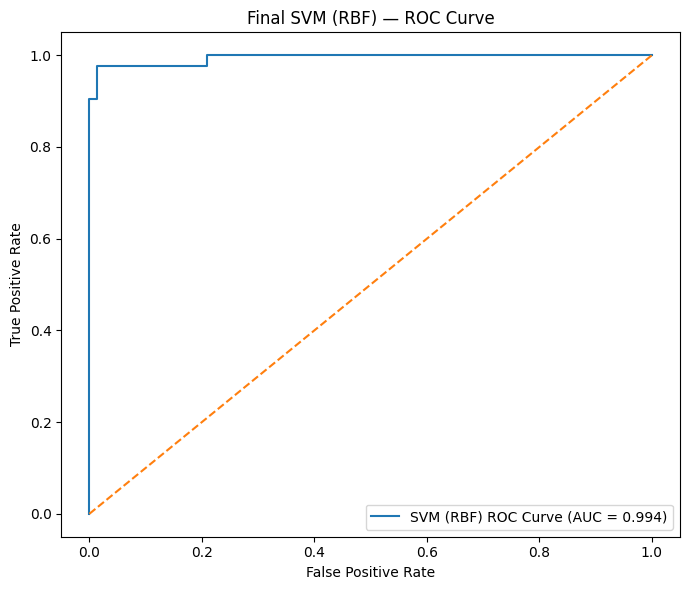

AUC: 0.9940476190476191


In [ ]:
# ============================================================
# 7. ROC Curve for Final SVM Model
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"SVM (RBF) ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final SVM (RBF) — ROC Curve")
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("roc_curve_svm_rbf.png", dpi=300, bbox_inches="tight")
plt.show()

print("AUC:", roc_auc)

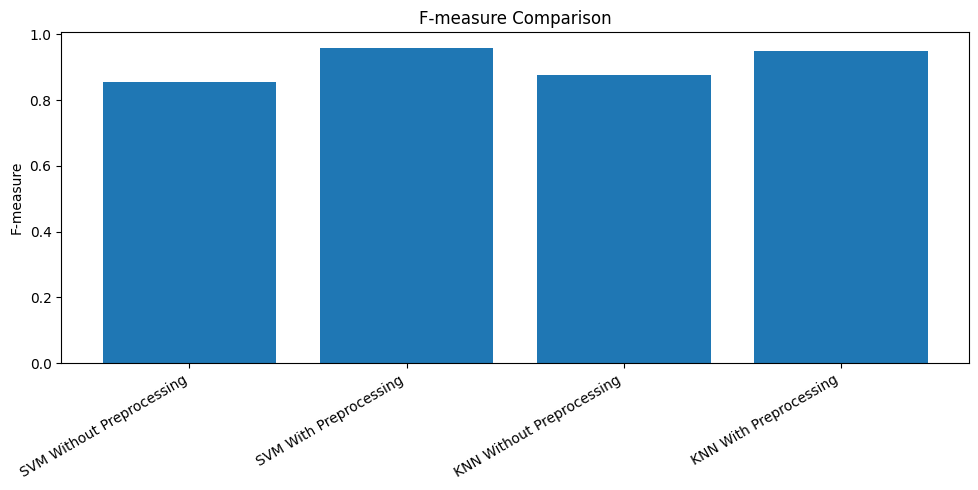

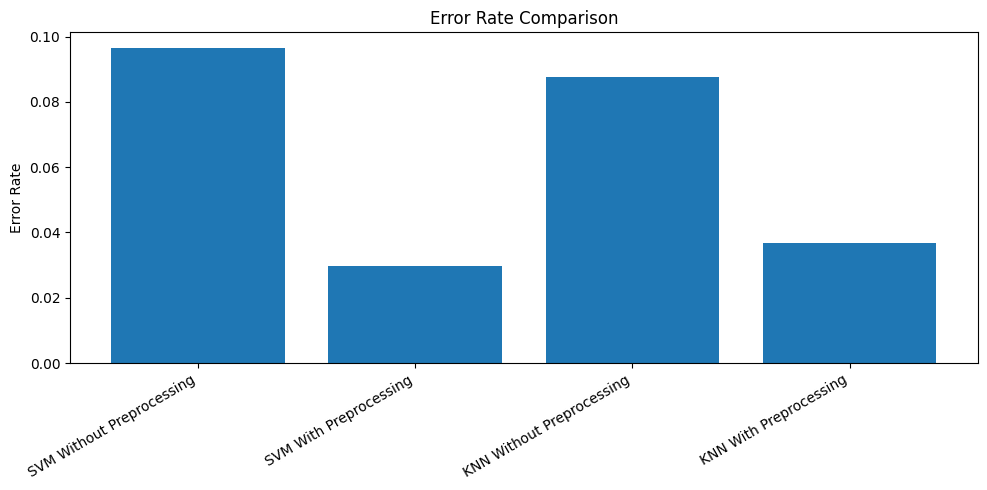

In [ ]:
# ============================================================
# 8. Performance Comparison: Protocol 1 vs Protocol 2
# ============================================================

comparison_data = pd.DataFrame({
    "Protocol": [
        "SVM Without Preprocessing",
        "SVM With Preprocessing",
        "KNN Without Preprocessing",
        "KNN With Preprocessing"
    ],
    "Error Rate": [
        0.096491,
        0.029825,
        0.087719,
        0.036842
    ],
    "F-measure": [
        0.856470,
        0.958481,
        0.877961,
        0.948570
    ]
})

plt.figure(figsize=(10, 5))
plt.bar(comparison_data["Protocol"], comparison_data["F-measure"])
plt.title("F-measure Comparison")
plt.ylabel("F-measure")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("fmeasure_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(comparison_data["Protocol"], comparison_data["Error Rate"])
plt.title("Error Rate Comparison")
plt.ylabel("Error Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("error_rate_comparison.png", dpi=300, bbox_inches="tight")
plt.show()